In [8]:
# Install the Kaggle API client library
!pip install kaggle

# Create a directory for Kaggle credentials
!mkdir ~/.kaggle

# Upload your kaggle.json file
# A file picker will appear. Select the kaggle.json file you downloaded earlier.
from google.colab import files
files.upload()

# Move the uploaded kaggle.json to the correct directory
!mv kaggle.json ~/.kaggle/kaggle.json

# Set permissions for the API key (important for security)
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key uploaded and configured!")

mkdir: cannot create directory ‘/root/.kaggle’: File exists


Saving kaggle.json to kaggle.json
Kaggle API key uploaded and configured!


In [9]:
import kagglehub

# Download latest version of the dataset
# Replace "rm1000/lung-cancer-histopathological-images" with the correct dataset slug
# You can find the slug from the Kaggle dataset URL (e.g., kaggle.com/datasets/SLUG_HERE)
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

# List the contents of the downloaded path to understand the structure
import os
print("\nContents of the downloaded directory:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

100%|██████████| 1.55G/1.55G [00:14<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rm1000/lung-cancer-histopathological-images/versions/1

Contents of the downloaded directory:
1/
    squamous_cell_carcinoma/
        0935.jpg
        0123.jpg
        2199.jpg
        1431.jpg
        1779.jpg
        1846.jpg
        2776.jpg
        2418.jpg
        3264.jpg
        0379.jpg
        3476.jpg
        0237.jpg
        4922.jpg
        3817.jpg
        4110.jpg
        1780.jpg
        3014.jpg
        4633.jpg
        1350.jpg
        0288.jpg
        2748.jpg
        0955.jpg
        3912.jpg
        0855.jpg
        4948.jpg
        0556.jpg
        3493.jpg
        0701.jpg
        1435.jpg
        3335.jpg
        3419.jpg
        0884.jpg
        0200.jpg
        3100.jpg
        3106.jpg
        4355.jpg
        0749.jpg
        2353.jpg
        0070.jpg
        1199.jpg
        4812.jpg
        4818.jpg
        2818.jpg
        1182.jpg
        3448.jpg
        1012.jpg
        3609.jpg
        1932.jpg
   

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

# Kaggle dataset path
dataset_path = "/root/.cache/kagglehub/datasets/rm1000/lung-cancer-histopathological-images/versions/1"
batch_size = 16
img_size = (224, 224)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
])

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
)

# Preprocess data
train_ds = train_ds.map(lambda x, y: (data_augmentation(x) / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Model architecture
model = Sequential([
    Rescaling(1.0 / 255, input_shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.3),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.3),
    Conv2D(256, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.4),
    GlobalAveragePooling2D(),
    Dense(512, activation="relu"),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax"),
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Callbacks
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss"),
]

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
)

# Save model
model.save("lung_cancer_model_final.h5")

# Plot results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")

plt.show()

Found 15000 files belonging to 3 classes.
Using 12000 files for training.
Found 15000 files belonging to 3 classes.
Using 3000 files for validation.
Epoch 1/30


KeyboardInterrupt: 

Found 15000 files belonging to 3 classes.
Using 12000 files for training.
Found 15000 files belonging to 3 classes.
Using 3000 files for validation.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 172s 212ms/step - accuracy: 0.7802 - loss: 0.5318 - val_accuracy: 0.3397 - val_loss: 2.0399 - learning_rate: 0.0010
Epoch 2/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.8781 - loss: 0.3170 - val_accuracy: 0.8153 - val_loss: 0.4137 - learning_rate: 0.0010
Epoch 3/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8925 - loss: 0.2759 - val_accuracy: 0.8510 - val_loss: 0.3009 - learning_rate: 0.0010
Epoch 4/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9027 - loss: 0.2573 - val_accuracy: 0.8313 - val_loss: 0.4293 - learning_rate: 0.0010
Epoch 5/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9080 - loss: 0.2304 - val_accuracy: 0.9263 - val_loss: 0.1805 - learning_rate: 0.0010
Epoch 6/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9185 - loss: 0.2172 - val_accuracy: 0.9003 - val_loss: 0.2307 - learning_rate: 0.0010
Epoch 7/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9288 -

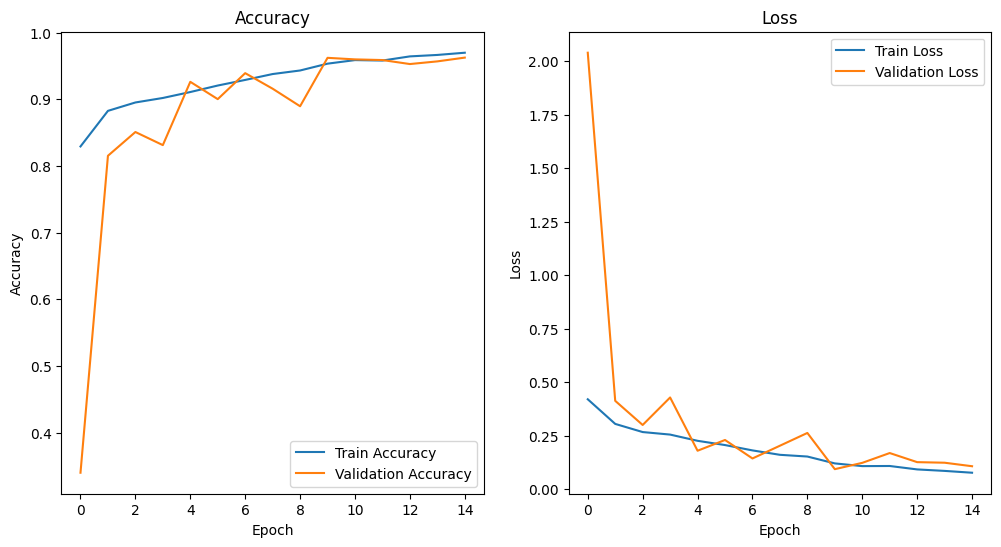

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

# Kaggle dataset path
dataset_path = "/root/.cache/kagglehub/datasets/rm1000/lung-cancer-histopathological-images/versions/1"
batch_size = 16
img_size = (192, 192)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
])

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
)

# Preprocess data
train_ds = train_ds.map(lambda x, y: (data_augmentation(x) / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Model architecture
model = Sequential([
    Rescaling(1.0 / 255, input_shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.3),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.3),
    Conv2D(256, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.4),
    GlobalAveragePooling2D(),
    Dense(512, activation="relu"),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax"),
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Callbacks
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss"),
]

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
)

# Save model
model.save("lung_cancer_model_final.h5")

# Plot results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")

plt.show()

In [2]:
!ls -lh
from google.colab import files
files.download('lung_cancer_model_final.h5')  # or 'your_model.keras'


total 14M
-rw-r--r-- 1 root root 6.9M May 21 16:01 best_model.keras
-rw-r--r-- 1 root root 6.9M May 21 16:03 lung_cancer_model_final.h5
drwxr-xr-x 1 root root 4.0K May 14 13:38 sample_data


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>